In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

2026-05-23 19:23:41.984979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
RESULTS_DIR = "/home/jovyan/results"
MODELS_DIR = "/home/jovyan/models"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 15
LEARNING_RATE = 5e-6

In [3]:
train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train_split_5class.csv"))
val_df = pd.read_csv(os.path.join(RESULTS_DIR, "val_split_5class.csv"))
test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test_split_5class.csv"))

In [4]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

print("\nLabels:")
print(train_df["label"].value_counts().sort_index())

Train: 7025
Validation: 781
Test: 1952

Train distribution:
dx
nv       4827
mel       801
bkl       791
bcc       370
akiec     236
Name: count, dtype: int64

Validation distribution:
dx
nv       537
mel       89
bkl       88
bcc       41
akiec     26
Name: count, dtype: int64

Test distribution:
dx
nv       1341
mel       223
bkl       220
bcc       103
akiec      65
Name: count, dtype: int64

Labels:
label
0     236
1     370
2     791
3     801
4    4827
Name: count, dtype: int64


In [5]:
remove_classes = ["df", "vasc"]

train_df = train_df[~train_df["dx"].isin(remove_classes)]
val_df = val_df[~val_df["dx"].isin(remove_classes)]
test_df = test_df[~test_df["dx"].isin(remove_classes)]

print(len(train_df), len(val_df), len(test_df))

7025 781 1952


In [6]:
label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "mel": 3,
    "nv": 4
}

train_df["label"] = train_df["dx"].map(label_map)
val_df["label"] = val_df["dx"].map(label_map)
test_df["label"] = test_df["dx"].map(label_map)

In [7]:
classes = np.sort(train_df["label"].unique())

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(c): min(float(w), 2.0)
    for c, w in zip(classes, class_weights_array)}

print(class_weights)

{0: 2.0, 1: 2.0, 2: 1.7762326169405815, 3: 1.7540574282147317, 4: 0.29107105862854776}


In [8]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    image = preprocess_input(image)

    return image, label

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values))

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values))

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label"].values))

train_ds = (
    train_ds
    .map(load_image)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = (
    val_ds
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

test_ds = (
    test_ds
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

I0000 00:00:1779564237.841308   29539 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12695 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:2a:00.0, compute capability: 8.6


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [11]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [12]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,072 (16.83 MB)

 Trainable params: 1,858,149 (7.09 MB)

 Non-trainable params: 2,553,923 (9.74 MB)

In [14]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15


E0000 00:00:1779558944.405600     659 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-23 17:55:55.516981: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


220/220 ━━━━━━━━━━━━━━━━━━━━ 62s 186ms/step - accuracy: 0.2910 - loss: 1.5908 - val_accuracy: 0.4097 - val_loss: 1.4100
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 46s 197ms/step - accuracy: 0.3532 - loss: 1.4269 - val_accuracy: 0.5045 - val_loss: 1.2611
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 197ms/step - accuracy: 0.4154 - loss: 1.2972 - val_accuracy: 0.5467 - val_loss: 1.1587
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 196ms/step - accuracy: 0.4416 - loss: 1.2294 - val_accuracy: 0.5685 - val_loss: 1.0918
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 196ms/step - accuracy: 0.4836 - loss: 1.1587 - val_accuracy: 0.5851 - val_loss: 1.0395
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 194ms/step - accuracy: 0.5002 - loss: 1.1108 - val_accuracy: 0.6018 - val_loss: 1.0047
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 190ms/step - accuracy: 0.5127 - loss: 1.0757 - val_accuracy: 0.6095 - val_loss: 0.9793
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 191ms/step - accuracy: 0.5349 - loss: 1.0411 - val

In [16]:
model.save(os.path.join(MODELS_DIR, "efficientnet_5class1_2.0.keras"))

In [17]:
y_true = np.concatenate([
    y for x, y in test_ds
])

y_probs = model.predict(test_ds)

y_pred = np.argmax(y_probs, axis=1)

2026-05-23 18:09:55.121527: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step


In [28]:
import pandas as pd
import numpy as np

history_df = pd.DataFrame(history.history)

print(history_df)

best_val_acc_epoch = history_df["val_accuracy"].idxmax() + 1
best_val_loss_epoch = history_df["val_loss"].idxmin() + 1

print("Final training accuracy:", history_df["accuracy"].iloc[-1])
print("Final validation accuracy:", history_df["val_accuracy"].iloc[-1])
print("Final training loss:", history_df["loss"].iloc[-1])
print("Final validation loss:", history_df["val_loss"].iloc[-1])

print("Best validation accuracy:", history_df["val_accuracy"].max())
print("Best validation accuracy epoch:", best_val_acc_epoch)

print("Best validation loss:", history_df["val_loss"].min())
print("Best validation loss epoch:", best_val_loss_epoch)

history_df["generalization_gap"] = history_df["accuracy"] - history_df["val_accuracy"]

print("Final generalization gap:", history_df["generalization_gap"].iloc[-1])
print("Average generalization gap:", history_df["generalization_gap"].mean())

    accuracy      loss  val_accuracy  val_loss
0   0.290961  1.590837      0.409731  1.410021
1   0.353167  1.426908      0.504481  1.261147
2   0.415374  1.297247      0.546735  1.158739
3   0.441566  1.229388      0.568502  1.091784
4   0.483559  1.158727      0.585147  1.039545
5   0.500214  1.110823      0.601793  1.004725
6   0.512740  1.075748      0.609475  0.979268
7   0.534947  1.041088      0.614597  0.957705
8   0.544769  1.009816      0.617158  0.941837
9   0.561139  0.984249      0.624840  0.923777
10  0.574377  0.960018      0.633803  0.912230
11  0.577509  0.938316      0.644046  0.906454
12  0.593879  0.916056      0.655570  0.891879
13  0.611103  0.887371      0.665813  0.874944
14  0.613096  0.872528      0.663252  0.870863
Final training accuracy: 0.6130960583686829
Final validation accuracy: 0.6632522344589233
Final training loss: 0.8725281953811646
Final validation loss: 0.8708632588386536
Best validation accuracy: 0.6658130884170532
Best validation accuracy epoch:

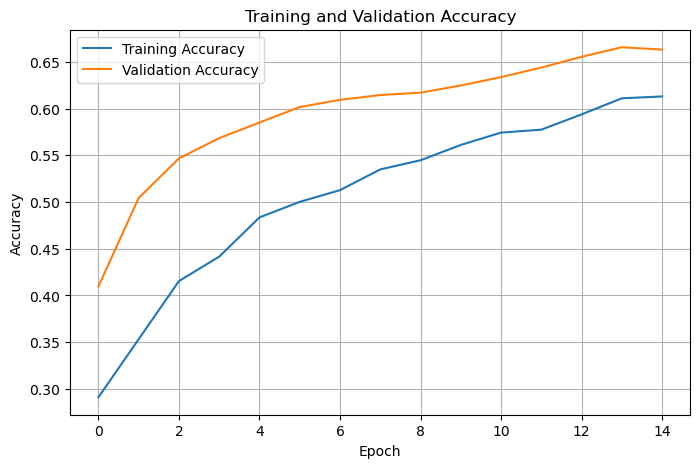

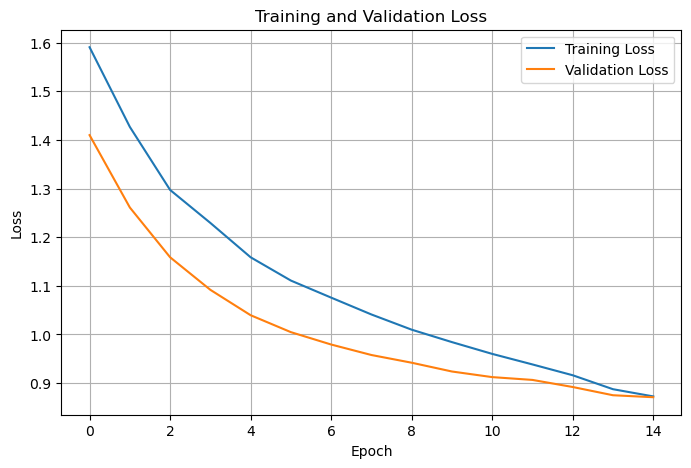

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
history_df["val_accuracy_change"] = history_df["val_accuracy"].diff().abs()
history_df["val_loss_change"] = history_df["val_loss"].diff().abs()

val_acc_instability = history_df["val_accuracy_change"].mean()
val_loss_instability = history_df["val_loss_change"].mean()

print("Validation accuracy instability:", val_acc_instability)
print("Validation loss instability:", val_loss_instability)

print("Validation accuracy standard deviation:", history_df["val_accuracy"].std())
print("Validation loss standard deviation:", history_df["val_loss"].std())

Validation accuracy instability: 0.018474487321717397
Validation loss instability: 0.03851127198764256
Validation accuracy standard deviation: 0.0680830406675667
Validation loss standard deviation: 0.1558439403580053


In [31]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

print("\nClassification Report:\n")

target_names = list(label_map.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

balanced_acc = balanced_accuracy_score(y_true, y_pred)

print("\nBalanced Accuracy:", balanced_acc)

[[ 15   9  29   9   3]
 [  7  49  29  13   5]
 [  5  10 145  36  24]
 [  7  14  61 115  26]
 [  8  32 140 224 937]]

Classification Report:

              precision    recall  f1-score   support

       akiec       0.36      0.23      0.28        65
         bcc       0.43      0.48      0.45       103
         bkl       0.36      0.66      0.46       220
         mel       0.29      0.52      0.37       223
          nv       0.94      0.70      0.80      1341

    accuracy                           0.65      1952
   macro avg       0.48      0.52      0.47      1952
weighted avg       0.76      0.65      0.68      1952


Balanced Accuracy: 0.5160031303601672


In [27]:
import numpy as np

cm = np.array([
    [15, 9, 29, 9, 3],
    [7, 49, 29, 13, 5],
    [5, 10, 145, 36, 24],
    [7, 14, 61, 115, 26],
    [8, 32, 140, 224, 937]
])

class_index = 3  # melanoma

tp = cm[class_index, class_index]
fn = np.sum(cm[class_index, :]) - tp
fp = np.sum(cm[:, class_index]) - tp
tn = np.sum(cm) - (tp + fn + fp)

specificity = tn / (tn + fp)

print("Melanoma Specificity:", specificity)

Melanoma Specificity: 0.8368999421631


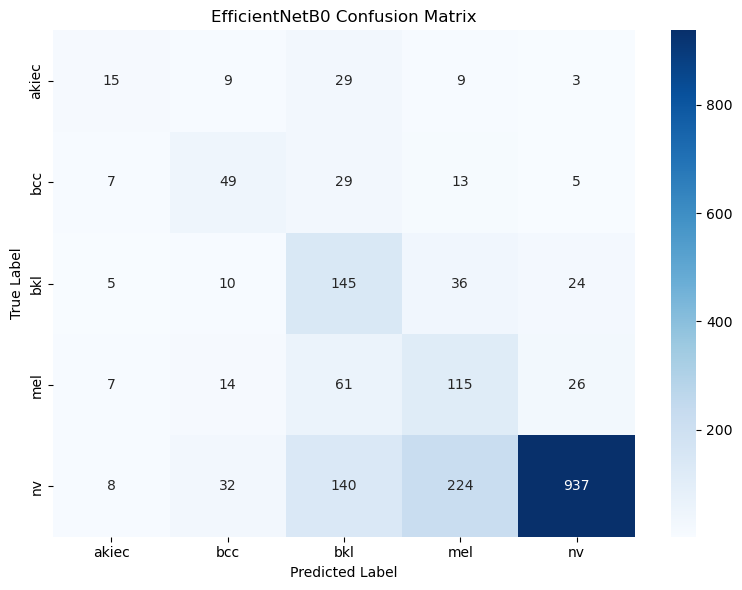

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([
    [15, 9, 29, 9, 3],
    [7, 49, 29, 13, 5],
    [5, 10, 145, 36, 24],
    [7, 14, 61, 115, 26],
    [8, 32, 140, 224, 937]
])

class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")

plt.tight_layout()

plt.savefig("/home/jovyan/results/efficientnet_confusion_matrix.png")

plt.show()

In [25]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

7025
781
1952
label
4    4827
3     801
2     791
1     370
0     236
Name: count, dtype: int64
label
4    1341
3     223
2     220
1     103
0      65
Name: count, dtype: int64


In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create output folder
output_dir = "efficientnet2_results"
os.makedirs(output_dir, exist_ok=True)

In [34]:
history_df = pd.DataFrame(history.history)

history_df["generalization_gap"] = (
    history_df["accuracy"] - history_df["val_accuracy"]
)

history_df["val_accuracy_change"] = history_df["val_accuracy"].diff().abs()
history_df["val_loss_change"] = history_df["val_loss"].diff().abs()

history_df.to_csv(f"{output_dir}/training_history.csv", index=False)

history_df

,accuracy,loss,val_accuracy,val_loss,generalization_gap,val_accuracy_change,val_loss_change
0,0.290961,1.590837,0.409731,1.410021,-0.118770,NaN,NaN
1,0.353167,1.426908,0.504481,1.261147,-0.151314,0.094750,0.148874
2,0.415374,1.297247,0.546735,1.158739,-0.131361,0.042253,0.102408
3,0.441566,1.229388,0.568502,1.091784,-0.126936,0.021767,0.066955
4,0.483559,1.158727,0.585147,1.039545,-0.101589,0.016645,0.052239
5,0.500214,1.110823,0.601793,1.004725,-0.101579,0.016645,0.034820
6,0.512740,1.075748,0.609475,0.979268,-0.096735,0.007682,0.025457
7,0.534947,1.041088,0.614597,0.957705,-0.079650,0.005122,0.021563
8,0.544769,1.009816,0.617158,0.941837,-0.072389,0.002561,0.015868
9,0.561139,0.984249,0.624840,0.923777,-0.063701,0.007682,0.018060


In [35]:
history_df = pd.DataFrame(history.history)

history_df["generalization_gap"] = (
    history_df["accuracy"] - history_df["val_accuracy"]
)

history_df["val_accuracy_change"] = history_df["val_accuracy"].diff().abs()
history_df["val_loss_change"] = history_df["val_loss"].diff().abs()

history_df.to_csv(f"{output_dir}/training_history.csv", index=False)

history_df

,accuracy,loss,val_accuracy,val_loss,generalization_gap,val_accuracy_change,val_loss_change
0,0.290961,1.590837,0.409731,1.410021,-0.118770,NaN,NaN
1,0.353167,1.426908,0.504481,1.261147,-0.151314,0.094750,0.148874
2,0.415374,1.297247,0.546735,1.158739,-0.131361,0.042253,0.102408
3,0.441566,1.229388,0.568502,1.091784,-0.126936,0.021767,0.066955
4,0.483559,1.158727,0.585147,1.039545,-0.101589,0.016645,0.052239
5,0.500214,1.110823,0.601793,1.004725,-0.101579,0.016645,0.034820
6,0.512740,1.075748,0.609475,0.979268,-0.096735,0.007682,0.025457
7,0.534947,1.041088,0.614597,0.957705,-0.079650,0.005122,0.021563
8,0.544769,1.009816,0.617158,0.941837,-0.072389,0.002561,0.015868
9,0.561139,0.984249,0.624840,0.923777,-0.063701,0.007682,0.018060


In [36]:
summary_metrics = {
    "Final Training Accuracy": history_df["accuracy"].iloc[-1],
    "Final Validation Accuracy": history_df["val_accuracy"].iloc[-1],
    "Final Training Loss": history_df["loss"].iloc[-1],
    "Final Validation Loss": history_df["val_loss"].iloc[-1],
    "Best Validation Accuracy": history_df["val_accuracy"].max(),
    "Best Validation Accuracy Epoch": history_df["val_accuracy"].idxmax() + 1,
    "Best Validation Loss": history_df["val_loss"].min(),
    "Best Validation Loss Epoch": history_df["val_loss"].idxmin() + 1,
    "Final Generalization Gap": history_df["generalization_gap"].iloc[-1],
    "Average Generalization Gap": history_df["generalization_gap"].mean(),
    "Validation Accuracy Instability": history_df["val_accuracy_change"].mean(),
    "Validation Loss Instability": history_df["val_loss_change"].mean(),
    "Validation Accuracy Std": history_df["val_accuracy"].std(),
    "Validation Loss Std": history_df["val_loss"].std()
}

summary_metrics_df = pd.DataFrame(
    summary_metrics.items(),
    columns=["Metric", "Value"]
)

summary_metrics_df.to_csv(f"{output_dir}/training_summary_metrics.csv", index=False)

summary_metrics_df

,Metric,Value
0,Final Training Accuracy,0.613096
1,Final Validation Accuracy,0.663252
2,Final Training Loss,0.872528
3,Final Validation Loss,0.870863
4,Best Validation Accuracy,0.665813
5,Best Validation Accuracy Epoch,14.000000
6,Best Validation Loss,0.870863
7,Best Validation Loss Epoch,15.000000
8,Final Generalization Gap,-0.050156
9,Average Generalization Gap,-0.089103


In [37]:
class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

cm_df.to_csv(f"{output_dir}/confusion_matrix.csv")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(f"{output_dir}/classification_report.csv")

report_df

,precision,recall,f1-score,support
akiec,0.357143,0.230769,0.280374,65.000000
bcc,0.429825,0.475728,0.451613,103.000000
bkl,0.358911,0.659091,0.464744,220.000000
mel,0.289673,0.515695,0.370968,223.000000
nv,0.941709,0.698732,0.802226,1341.000000
accuracy,0.646004,0.646004,0.646004,0.646004
macro avg,0.475452,0.516003,0.473985,1952.000000
weighted avg,0.755059,0.646004,0.679045,1952.000000


In [38]:
final_metrics = {
    "Test Accuracy": accuracy_score(y_true, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    "Macro Precision": precision_score(y_true, y_pred, average="macro"),
    "Macro Recall": recall_score(y_true, y_pred, average="macro"),
    "Macro F1": f1_score(y_true, y_pred, average="macro"),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted"),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted"),
    "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    "Melanoma Recall": recall_score(y_true, y_pred, labels=[3], average="macro")
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Value"]
)

final_metrics_df.to_csv(f"{output_dir}/final_test_metrics.csv", index=False)

final_metrics_df

,Metric,Value
0,Test Accuracy,0.646004
1,Balanced Accuracy,0.516003
2,Macro Precision,0.475452
3,Macro Recall,0.516003
4,Macro F1,0.473985
5,Weighted Precision,0.755059
6,Weighted Recall,0.646004
7,Weighted F1,0.679045
8,Melanoma Recall,0.515695


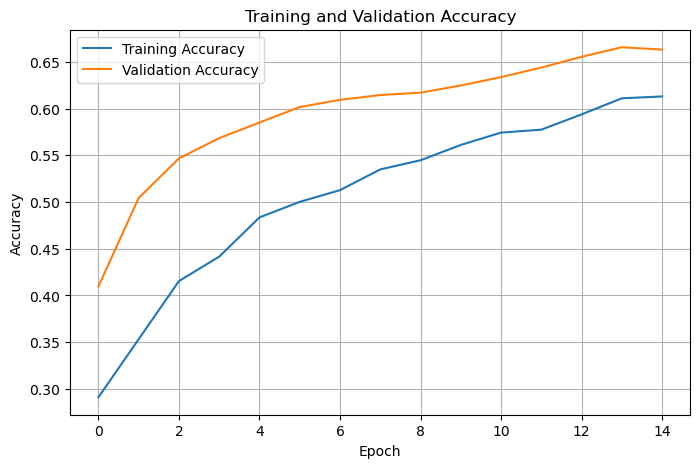

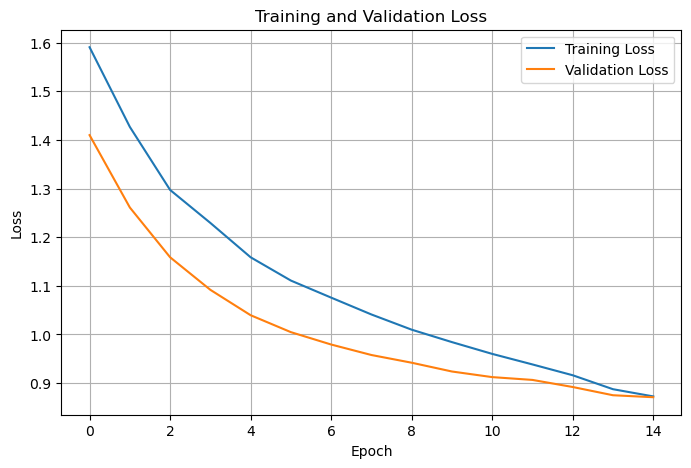

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/training_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

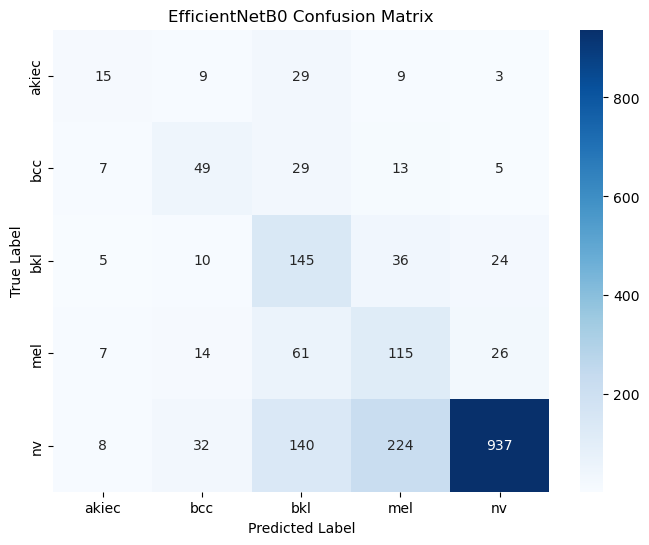

In [40]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")
plt.savefig(f"{output_dir}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
model.save(f"{output_dir}/efficientnetb0_5class_model.keras")